## Paso 1: Obtención de datos de la API de divisas
Consultamos la API pública de Frankfurter para obtener los tipos de cambio del Euro respecto a otras divisas y guardamos la información en un archivo CSV local.

In [ ]:
import requests
import pandas as pd

# 1. Pedimos los datos a la API de divisas
url = "https://api.frankfurter.dev/v1/latest?from=EUR"
respuesta = requests.get(url)
datos = respuesta.json()

# 2. Convertimos los datos de las divisas a un DataFrame (tabla)
tasas = datos["rates"]
df = pd.DataFrame(list(tasas.items()), columns=["Moneda", "Cambio"])

# 3. Añadimos la fecha de la consulta
df["Fecha"] = datos["date"]

# 4. Guardamos la tabla en un archivo CSV en Google Colab
df.to_csv("cambio_monedas.csv", index=False)

print("¡Archivo 'cambio_monedas.csv' generado con éxito!")

¡Archivo 'cambio_monedas.csv' generado con éxito!


## Paso 2: Lectura del CSV desde GitHub y Análisis Estadístico
Leemos el archivo CSV alojado públicamente en GitHub y calculamos los estadísticos principales (media, máximo, mínimo, etc.) del tipo de cambio.

In [3]:
import pandas as pd

# 1. Pon aquí la URL de tu archivo en GitHub (debe ser la URL que empieza por raw.githubusercontent.com)
url_github = "https://raw.githubusercontent.com/jaimealvarez77/trabajo-cambio-divisas/refs/heads/main/cambio_monedas.csv"

# 2. Leemos el CSV
df = pd.read_csv(url_github)

# 3. Calculamos los estadísticos principales
print("--- ESTADÍSTICAS DEL DATAFRAME ---")
print(df.describe())

--- ESTADÍSTICAS DEL DATAFRAME ---
             Cambio
count     29.000000
mean     784.831894
std     3735.123568
min        0.850330
25%        3.440800
50%        8.808400
75%       55.165000
max    20149.320000


## Paso 3: Visualización de datos
Generamos un gráfico de barras para comparar el tipo de cambio del Euro respecto a las primeras 10 divisas de la lista.

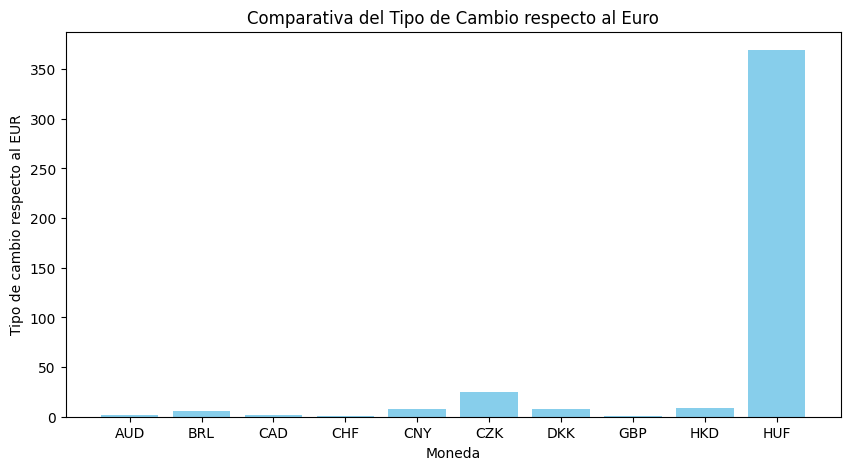

In [4]:
import matplotlib.pyplot as plt

# 1. Cogemos las primeras 10 monedas para que la gráfica no quede amontonada
df_reducido = df.head(10)

# 2. Creamos el gráfico de barras
plt.figure(figsize=(10, 5))
plt.bar(df_reducido["Moneda"], df_reducido["Cambio"], color="skyblue")

# 3. Añadimos títulos y etiquetas
plt.xlabel("Moneda")
plt.ylabel("Tipo de cambio respecto al EUR")
plt.title("Comparativa del Tipo de Cambio respecto al Euro")

# 4. Mostramos la gráfica
plt.show()